In [8]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "tanishakarande",\r\n  "key": "KGAT_32156562a17fa6f4fff6f0a33de46667"\r\n}\r\n'}

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Path to dataset files: /kaggle/input/covid19-radiography-database


In [10]:
import os
base_path = "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"
print(os.listdir(base_path))

['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']


In [11]:
covid_images = os.path.join(base_path, "COVID/images")
normal_images = os.path.join(base_path, "Normal/images")

print(f"Covid Images: {len(os.listdir(covid_images))}")
print(f"Normal Images: {len(os.listdir(normal_images))}")

Covid Images: 3616
Normal Images: 10192


In [12]:
working_dataset = "/kaggle/working/working_dataset"
covid_target  = os.path.join(working_dataset, "COVID")
normal_target = os.path.join(working_dataset, "Normal")
os.makedirs(covid_target, exist_ok=True)
os.makedirs(normal_target, exist_ok=True)

In [13]:
import shutil
for img in os.listdir(covid_images):
  src = os.path.join(covid_images, img)
  dst = os.path.join(covid_target, img)
  shutil.copy(src, dst)

In [14]:
for img in os.listdir(normal_images):
  src = os.path.join(normal_images, img)
  des = os.path.join(normal_target, img)
  shutil.copy(src, des)

In [15]:
print(f"COVID Images in working dataset: {len(os.listdir(covid_target))}")
print(f"Normal Images in working dataset: {len(os.listdir(normal_target))}")

COVID Images in working dataset: 3616
Normal Images in working dataset: 10192


In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    validation_split = 0.2
)
IMG_SIZE = (150, 150)
BATCH = 32

In [18]:
train_generator = train_datagen.flow_from_directory(
    working_dataset,
    target_size = IMG_SIZE,
    batch_size = BATCH,
    class_mode = "binary",
    subset = "training"
)

validation_generator = train_datagen.flow_from_directory(
    working_dataset,
    target_size = IMG_SIZE,
    batch_size = BATCH,
    class_mode = "binary",
    subset = "validation"
)

Found 11047 images belonging to 2 classes.
Found 2761 images belonging to 2 classes.


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import Input

In [20]:
model = Sequential()
model.add(Input(shape=(150, 150, 3)))
model.add(Conv2D(32, (3,3), activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
346/346 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.8089 - loss: 0.4205 - val_accuracy: 0.8881 - val_loss: 0.2877
Epoch 2/5
346/346 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9175 - loss: 0.2064 - val_accuracy: 0.9105 - val_loss: 0.1980
Epoch 3/5
346/346 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9493 - loss: 0.1389 - val_accuracy: 0.9290 - val_loss: 0.1961
Epoch 4/5
346/346 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9602 - loss: 0.1134 - val_accuracy: 0.9344 - val_loss: 0.1680
Epoch 5/5
346/346 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.9632 - loss: 0.0917 - val_accuracy: 0.9468 - val_loss: 0.1572


In [23]:
model.save("covid_xray_cnn.h5")

Saving COVID.png to COVID.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


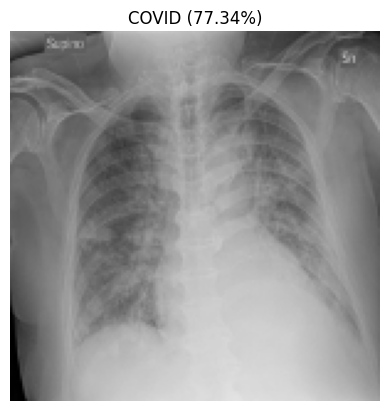

In [25]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

uploaded = files.upload()
img_name = list(uploaded.keys())[0]

img = image.load_img(img_name, target_size=(150,150))
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0][0]

if pred < 0.5:
    label = "COVID"
    confidence = (1 - pred) * 100
else:
    label = "Normal"
    confidence = pred * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"{label} ({confidence:.2f}%)")
plt.show()
